In [1]:
#Import Libs
from matplotlib import pyplot as plot
import matplotlib as mpl
import urllib.request
import urllib.parse
import numpy as np
import math
import cv2

In [2]:
#Function to Load a Image from Github
def display_image_from_url(image_url):
    with urllib.request.urlopen(image_url) as url:
        s = url.read()
    img = cv2.imdecode(np.frombuffer(s, np.uint8), -1)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

In [3]:
#Import Image
image_url = 'https://raw.githubusercontent.com/jrafa1607/Computational-Vision-In-Python/main/-%20Images/A_mac_01.jpg'
img = display_image_from_url(image_url)

In [4]:
#Import Template
template_url = 'https://raw.githubusercontent.com/jrafa1607/Computational-Vision-In-Python/main/-%20Images/T_mac.jpg'
template = display_image_from_url(template_url)

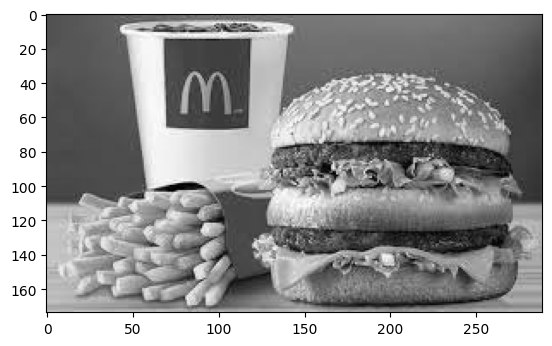

In [5]:
#Show the Image
plot.imshow(img,cmap='gray')
plot.show()

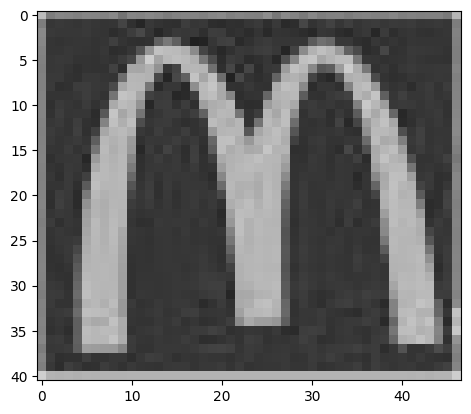

In [6]:
#Show the Template
plot.imshow(template,cmap='gray')
plot.show()

In [7]:
#Show the Template Shape
template.shape

(41, 47, 3)

In [8]:
#Get the Shape Values
h = template.shape[0]
w = template.shape[1]

### **Template Matching in OpenCV**

**Template Matching** is a technique in computer vision for finding small parts of an image (template) within a larger image. It works by sliding the template image over the larger image and comparing them at each position.

OpenCV provides several methods for template matching, each employing a different mathematical approach to compare the template with regions of the source image. The result of template matching is typically a grayscale image, where each pixel indicates how well the template matches the area under that pixel. The brighter areas usually indicate a better match.

Here are the common methods available in OpenCV:

*   **`cv2.TM_SQDIFF` (Squared Difference Matching)**:
    This method calculates the squared difference between the template and the image patch. The best match is indicated by the *minimum* value, as smaller differences mean a better match. The result image will have its global minimum at the best match location.

*   **`cv2.TM_SQDIFF_NORMED` (Normalized Squared Difference Matching)**:
    Similar to `TM_SQDIFF`, but the results are normalized by the area of the template. This makes the method more robust to changes in illumination and image content. Again, the best match corresponds to the *minimum* value.

*   **`cv2.TM_CCOEFF` (Cross-Correlation Matching)**:
    This method calculates the cross-correlation between the template and the image patch. Higher values indicate a better match. The best match is indicated by the *maximum* value.

*   **`cv2.TM_CCOEFF_NORMED` (Normalized Cross-Correlation Matching)**:
    A normalized version of `TM_CCOEFF`. The results are scaled to a range of 0 to 1, where 1 signifies a perfect match. This is generally one of the most robust and popular methods due to its resistance to illumination changes. The best match corresponds to the *maximum* value.

*   **`cv2.TM_CCORR` (Cross-Correlation Matching)**:
    This method calculates the cross-correlation between the template and the image patch without normalization. Higher values indicate a better match. The best match is indicated by the *maximum* value.

*   **`cv2.TM_CCORR_NORMED` (Normalized Cross-Correlation Matching)**:
    Similar to `TM_CCORR`, but normalized. Higher values (closer to 1) indicate a better match, and the best match is indicated by the *maximum* value.

**How to interpret the results:** For `TM_SQDIFF` and `TM_SQDIFF_NORMED`, the *minimum* value in the result matrix indicates the best match. For all other methods (`TM_CCOEFF`, `TM_CCOEFF_NORMED`, `TM_CCORR`, `TM_CCORR_NORMED`), the *maximum* value indicates the best match.

After obtaining the result matrix, you typically use `cv2.minMaxLoc()` to find the minimum or maximum value and its location, which corresponds to the top-left corner of the best-matched region in the original image.

**Important:** When performing template matching with methods like `cv2.TM_SQDIFF` or `cv2.TM_SQDIFF_NORMED`, the goal is to find the *minimum* difference between the template and the image region. A smaller difference indicates a better match.

Therefore, you look for the location (`min_loc`) corresponding to the minimum value (`min_val`) in the result matrix.

For all other template matching methods, such as `cv2.TM_CCOEFF`, `cv2.TM_CCOEFF_NORMED`, `cv2.TM_CCORR`, and `cv2.TM_CCORR_NORMED`, the comparison metric calculates a form of correlation or similarity. In these cases, a *higher* value indicates a better match. Thus, you look for the location (`max_loc`) corresponding to the maximum value (`max_val`) in the result matrix.

The `cv2.minMaxLoc()` function conveniently returns both the minimum and maximum values and their respective locations, allowing you to choose the appropriate one based on the template matching method used. So:

*   **Sqdiff / Sqdiff_Normed:** top_left = max_loc
*   **Other Methods:** top_left = min_loc

In [9]:
#Apply Template Matching
res = cv2.matchTemplate(img,template,cv2.TM_CCOEFF_NORMED)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

In [10]:
#TopLeft Definition
top_left = max_loc

In [11]:
#Add the Box
bottom_right = (top_left[0] + w, top_left[1] + h)
cv2.rectangle(img,top_left, bottom_right, (0,255,0), 2);

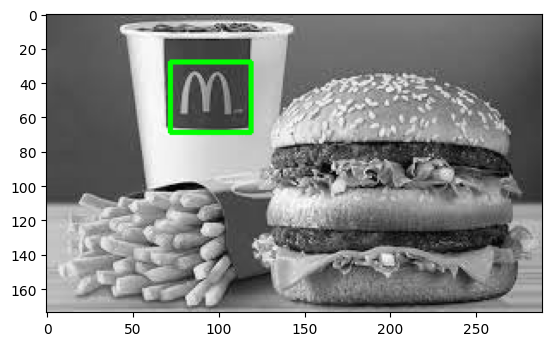

In [12]:
#Show the Template Detection
plot.imshow(img,cmap = 'gray')
plot.show()

In [13]:
#Example with Multiple Templates

In [14]:
#Import Image
image_url = 'https://raw.githubusercontent.com/jrafa1607/Computational-Vision-In-Python/main/-%20Images/A_mac_11.jpg'
img = display_image_from_url(image_url)

In [15]:
#Import Template
template_url = 'https://raw.githubusercontent.com/jrafa1607/Computational-Vision-In-Python/main/-%20Images/T_mac2.jpg'
template = display_image_from_url(template_url)

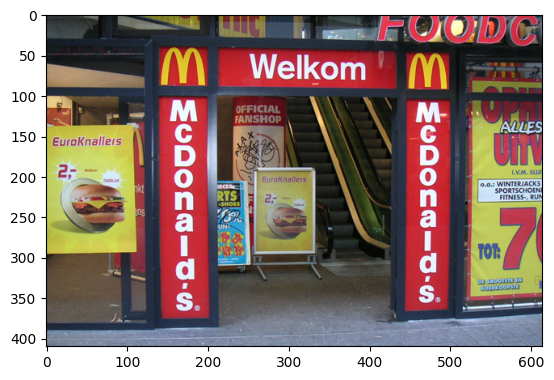

In [16]:
#Show the Image
plot.imshow(img,cmap='gray')
plot.show()

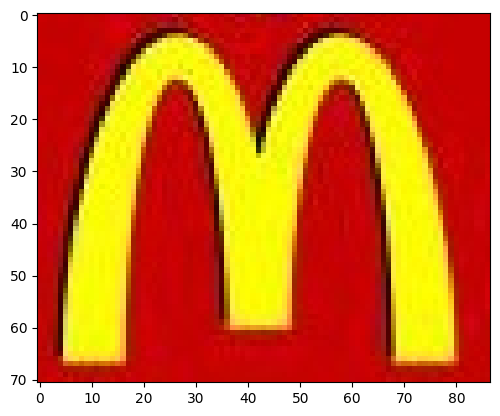

In [17]:
#Show the Template
plot.imshow(template,cmap='gray')
plot.show()

In [18]:
#Show the Template Shape
template.shape

(71, 87, 3)

In [19]:
#Get the Shape Values ( Need to Customize the Size )
h = int(template.shape[0]/1.3)
w = int(template.shape[1]/1.3)

In [20]:
#Template Dimension Definition
dim = (w,h)
template = cv2.resize(template, dim, interpolation = cv2.INTER_CUBIC)

In [21]:
#Template Matching Application
res = cv2.matchTemplate(img,template,cv2.TM_CCORR_NORMED)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

In [22]:
#Threshold Definition
threshold = 0.83
loc = np.where(res >= threshold)

In [23]:
#Define the Start Point and a Counter
top_left_ant = (0, 0)
cont=1

In [24]:
#Find the Coordinate and Validate Template
for i in range (len(loc[0])):
    top_left = (loc[1][i], loc[0][i])
    bottom_right = (top_left[0] + w, top_left[1] + h)

    if top_left[0] > top_left_ant[0] + w or top_left[1] > top_left_ant[1] + h:
      cv2.rectangle(img,top_left, bottom_right, (0,255,0), 2)
      cv2.putText(img,str(cont), bottom_right,1,2,(0,255,0),3,1)

      top_left_ant = top_left
      cont = cont + 1

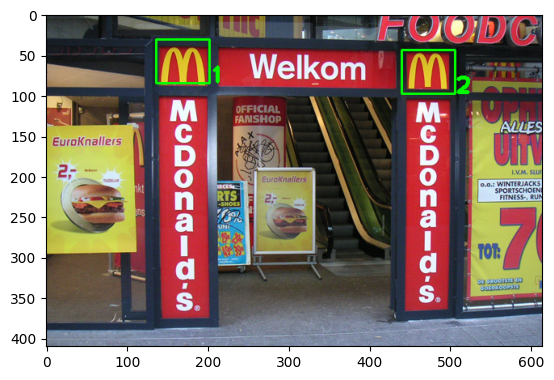

In [25]:
#Show the Results ( Multiple Template Matching )
plot.imshow(img,cmap = 'gray')
plot.show()